In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df1 = pd.read_csv('../data/main_nfcorpus_llms.csv')
df2 = pd.read_csv('../data/main_rags.csv')
df3 = pd.read_csv('../data/utility_leakage.csv')
df4 = pd.read_csv('../data/with_defense.csv')

# Concatenate them along the columns (axis=1) if they have the same row indices
df = pd.concat([df1, df2, df3, df4], axis=0).drop(columns=['SS','answer_relevancy', 'answer_infodepth', 'faithfulness'])

In [2]:
df.head()

,attack,dataset,rag,llm,CCL,STL,ARC,CRR,ULR,ASR,ARE,CLF
0,TGTB,NFcorpus,vanilla,Qwen-2.5-7B,98.0,44.0,364.0,0.6176,NaN,NaN,NaN,NaN
1,TGTB,NFcorpus,+RR,Qwen-2.5-7B,99.0,45.0,371.0,0.7062,NaN,NaN,NaN,NaN
2,TGTB,NFcorpus,+RR+RW,Qwen-2.5-7B,80.0,36.0,307.0,0.6970,NaN,NaN,NaN,NaN
3,GEN-PIDE,NFcorpus,vanilla,Qwen-2.5-7B,61.0,93.0,130.0,0.9333,NaN,NaN,NaN,NaN
4,GEN-PIDE,NFcorpus,+RR,Qwen-2.5-7B,53.0,92.0,157.0,0.9146,NaN,NaN,NaN,NaN


In [3]:
df["ASR"] = df["ASR"] /200
df["ULR"] = df["ULR"] /1000
df["ARE"] = df["ARE"] /1000

In [4]:
df["ASR_x_ARE"] = df["ASR"] * df["ARE"]
df['delta_TE'] = abs(df['ASR_x_ARE'] - df['ULR'])

In [5]:
df

,attack,dataset,rag,llm,CCL,STL,ARC,CRR,ULR,ASR,ARE,CLF,ASR_x_ARE,delta_TE
0,TGTB,NFcorpus,vanilla,Qwen-2.5-7B,98.0,44.0,364.0,0.6176,NaN,NaN,NaN,NaN,NaN,NaN
1,TGTB,NFcorpus,+RR,Qwen-2.5-7B,99.0,45.0,371.0,0.7062,NaN,NaN,NaN,NaN,NaN,NaN
2,TGTB,NFcorpus,+RR+RW,Qwen-2.5-7B,80.0,36.0,307.0,0.6970,NaN,NaN,NaN,NaN,NaN,NaN
3,GEN-PIDE,NFcorpus,vanilla,Qwen-2.5-7B,61.0,93.0,130.0,0.9333,NaN,NaN,NaN,NaN,NaN,NaN
4,GEN-PIDE,NFcorpus,+RR,Qwen-2.5-7B,53.0,92.0,157.0,0.9146,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,IKEA,EnronEmail,+RR+RW+IF,Qwen2.5-14B,NaN,NaN,NaN,NaN,0.0,0.0,0.385,0.0,0.0,0.0
63,IKEA,EnronEmail,+RR+RW+IF,DeepSeek-V3,NaN,NaN,NaN,NaN,0.0,0.0,0.423,0.0,0.0,0.0
64,DGEA,EnronEmail,+RR+RW+IF,o4-mini,NaN,NaN,NaN,NaN,0.0,0.0,0.356,0.0,0.0,0.0
65,DGEA,EnronEmail,+RR+RW+IF,Qwen2.5-14B,NaN,NaN,NaN,NaN,0.0,0.0,0.294,0.0,0.0,0.0


In [6]:
# 数据集名称列表
datasets = ['FiQA', 'NFcorpus', 'SciFact', 'EnronEmail']
metrics = ['ASR', 'ULR', 'ARE', 'CLF']

df_split_by_datasets = [df[df['dataset'] == dataset] for dataset in datasets]

In [7]:
# plot_df = (
#     df
#     .groupby("attack", as_index=False)
#     .agg({
#         "ASR": "mean",
#         "ULR": "mean",
#         "ARE": "mean"
#     })
# )
plot_df =  df.copy()

# plot_df["ASR_x_ARE"] = plot_df["ASR"] * plot_df["ARE"]
# plot_df['delta_TE'] = plot_df['ASR_x_ARE'] - plot_df['ULR']
print(plot_df['delta_TE'].var())

0.010489139545430612


In [8]:
plot_df = plot_df[plot_df['attack'] != 'WBTQ']

In [9]:
custom_order = ['TGTB', 'GEN-PIDE', 'PoR', 'DGEA', 'IKEA', 'RAG-Thief*', 'RAG-Thief'] # 你想要的顺序
plot_df['attack'] = pd.Categorical(plot_df['attack'], categories=custom_order, ordered=True)
plot_df = plot_df.sort_values('attack')

In [10]:
plot_df

,attack,dataset,rag,llm,CCL,STL,ARC,CRR,ULR,ASR,ARE,CLF,ASR_x_ARE,delta_TE
0,TGTB,NFcorpus,vanilla,Qwen-2.5-7B,98.0,44.0,364.0,0.6176,NaN,NaN,NaN,NaN,NaN,NaN
190,TGTB,FiQA,+RR,o4-mini,562.0,169.0,679.0,0.9346,NaN,NaN,NaN,NaN,NaN,NaN
191,TGTB,FiQA,+RR+RW,o4-mini,501.0,157.0,641.0,0.9449,NaN,NaN,NaN,NaN,NaN,NaN
128,TGTB,NFcorpus,+RR+RW,Doubao-1.6-flash,201.0,91.0,295.0,0.9292,NaN,NaN,NaN,NaN,NaN,NaN
127,TGTB,NFcorpus,+RR,Doubao-1.6-flash,226.0,83.0,383.0,0.9507,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,RAG-Thief,EnronEmail,+RR,DeepSeek-V3,634.0,194.0,748.0,0.9715,NaN,NaN,NaN,NaN,NaN,NaN
186,RAG-Thief,EnronEmail,vanilla,DeepSeek-V3,654.0,195.0,747.0,0.9699,NaN,NaN,NaN,NaN,NaN,NaN
145,RAG-Thief,NFcorpus,+RR,Doubao-1.6-flash,446.0,200.0,461.0,0.9979,NaN,NaN,NaN,NaN,NaN,NaN
10,RAG-Thief,SciFact,+RR+RW+IF,DeepSeek-V3,NaN,NaN,NaN,NaN,0.0,0.0,0.383,0.0,0.0,0.0


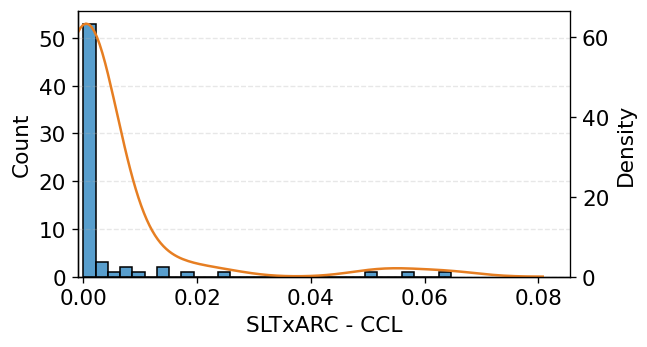

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 清理 NaN
data_clean = plot_df['delta_TE'].dropna()

fig, ax = plt.subplots(figsize=(5.5, 3), dpi=120)

# --------------------------
# 左轴：柱子显示 count
# --------------------------
sns.histplot(
    data_clean,
    bins=30,           # 柱子数量，可调节细粒度
    color='#2E86C1',
    alpha=0.8,
    ax=ax,
    stat='count'
)

# --------------------------
# 右轴：KDE 曲线
# --------------------------
ax2 = ax.twinx()
sns.kdeplot(
    data_clean,
    ax=ax2,               # KDE 放在右轴上
    color='#E67E22',      # 橙色线
    linewidth=1.5,
    label='KDE'
)

# 设置 X 轴起点
ax.set_xlim(-0.001, None)  # 从 -0.001 开始，右侧自动扩展

# --------------------------
# 标签和风格
# --------------------------
ax.set_xlabel("SLTxARC - CCL", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.tick_params(axis='both', labelsize=13)

ax2.set_ylabel("Density", fontsize=13)
ax2.tick_params(axis='y', labelsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# --------------------------
# 图例
# --------------------------
lines_labels = ax2.get_lines()  # 只包含 KDE
labels = [l.get_label() for l in lines_labels]
# ax2.legend(lines_labels, labels, loc='upper right', fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig(
    "asrxare_delta_distribution_count_kde.pdf",
    format='pdf',
    bbox_inches='tight',
    transparent=True,
    dpi=300
)
plt.show()


最大差距对应的行:
   attack dataset        rag          llm  CCL  STL  ARC  CRR   ULR   ASR  \
34   DGEA    FiQA  +RR+RW+IF  DeepSeek-V3  NaN  NaN  NaN  NaN  0.07  0.04   

      ARE  CLF  ASR_x_ARE  delta_TE  
34  0.134  0.0    0.00536   0.06464  
最小差距对应的行:
       attack     dataset        rag          llm  CCL  STL  ARC  CRR  ULR  \
0        TGTB     SciFact  +RR+RW+IF      o4-mini  NaN  NaN  NaN  NaN  0.0   
1        TGTB     SciFact  +RR+RW+IF  Qwen2.5-14B  NaN  NaN  NaN  NaN  0.0   
2        TGTB     SciFact  +RR+RW+IF  DeepSeek-V3  NaN  NaN  NaN  NaN  0.0   
36       TGTB    NFcorpus  +RR+RW+IF  Qwen2.5-14B  NaN  NaN  NaN  NaN  0.0   
37       TGTB    NFcorpus  +RR+RW+IF  DeepSeek-V3  NaN  NaN  NaN  NaN  0.0   
53       TGTB  EnronEmail  +RR+RW+IF  DeepSeek-V3  NaN  NaN  NaN  NaN  0.0   
52       TGTB  EnronEmail  +RR+RW+IF  Qwen2.5-14B  NaN  NaN  NaN  NaN  0.0   
51       TGTB  EnronEmail  +RR+RW+IF      o4-mini  NaN  NaN  NaN  NaN  0.0   
35       TGTB    NFcorpus  +RR+RW+IF      o4-mi

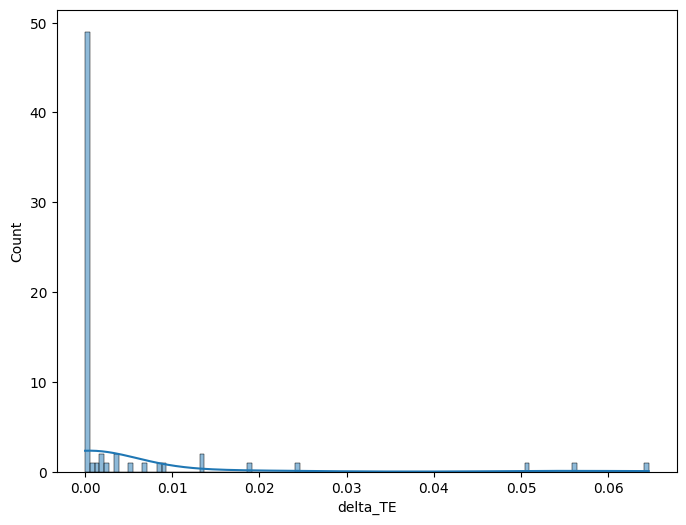

In [23]:
plt.figure(figsize=(8, 6))

# 使用直方图
sns.histplot(plot_df['delta_TE'], kde=True)
plt.savefig("asrxare_delta_distribution.pdf", format='pdf', bbox_inches='tight', transparent=True, dpi=300)


# 找出差距的最大值和最小值
max_diff = plot_df['delta_TE'].max()
min_diff = plot_df['delta_TE'].min()

# 找出对应的行
max_diff_row = plot_df[plot_df['delta_TE'] == max_diff]
min_diff_row = plot_df[plot_df['delta_TE'] == min_diff]

# 打印最大值和最小值对应的行
print(f"最大差距对应的行:\n{max_diff_row}")
print(f"最小差距对应的行:\n{min_diff_row}")

In [12]:
plot_df = (
    df
    .groupby("attack", as_index=False)
    .agg({
        "ASR": "mean",
        "ULR": "mean",
        "ARE": "mean",
        "delta_TE": "var",
        "ASR_x_ARE": "mean"
    })
)
print(plot_df['delta_TE'].var())

plot_df = plot_df[plot_df['attack'] != 'WBTQ']
custom_order = ['TGTB', 'GEN-PIDE', 'PoR', 'DGEA', 'IKEA', 'RAG-Thief*', 'RAG-Thief'] # 你想要的顺序
plot_df['attack'] = pd.Categorical(plot_df['attack'], categories=custom_order, ordered=True)
plot_df = plot_df.sort_values('attack')

1.0643599182096305e-05


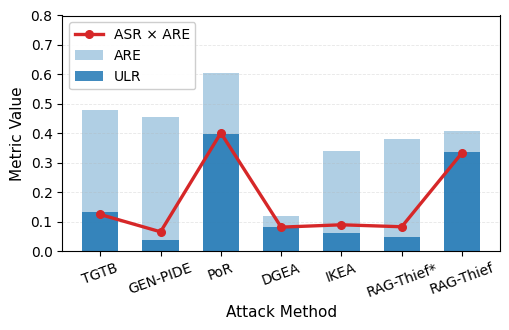

In [13]:
import matplotlib.pyplot as plt
import numpy as np

attacks = plot_df["attack"]
x = np.arange(len(attacks))
bar_width = 0.6

# 单栏但有张力（和你给的图比例接近）
fig, ax = plt.subplots(figsize=(5.2, 3.4))

# =====================
# ARE：背景（浅蓝）
# =====================
ax.bar(
    x,
    plot_df["ARE"],
    width=bar_width,
    color="tab:blue",
    alpha=0.35,
    label="ARE",
    zorder=1
)

# =====================
# ULR：前景（深蓝）
# =====================
ax.bar(
    x,
    plot_df["ULR"],
    width=bar_width,
    color="tab:blue",
    alpha=0.85,
    label="ULR",
    zorder=2
)

# =====================
# ASR × ARE：红色折线
# =====================
ax.plot(
    x,
    plot_df["ASR_x_ARE"],
    color="tab:red",
    marker="o",
    markersize=5.5,
    linewidth=2.4,
    label="ASR × ARE",
    zorder=3
)

# =====================
# 坐标轴与样式
# =====================
ax.set_xlabel("Attack Method", fontsize=11)
ax.set_ylabel("Metric Value", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(attacks, rotation=20, fontsize=10)

ax.set_ylim(0, 0.8)
ax.tick_params(axis="y", labelsize=10)

# 图例：右上角，和你示例图一致
ax.legend(
    fontsize=10,
    frameon=True,
    framealpha=0.95,
    loc="upper left"
)

# 网格：非常轻
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

plt.tight_layout()
plt.show()


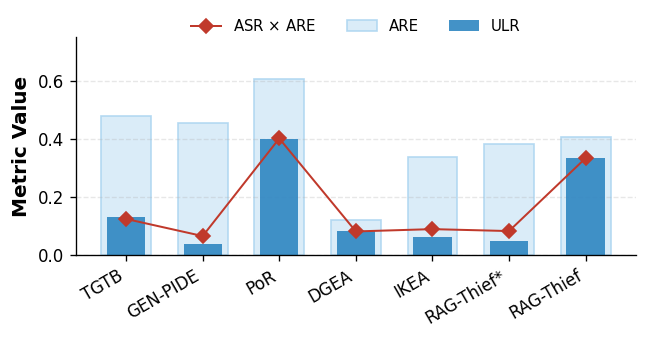

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. 绘图配置
fig, ax = plt.subplots(figsize=(5.5, 3), dpi=120)

x = np.arange(len(plot_df["attack"]))
width_base = 0.65  # 背景柱宽度
width_upper = 0.5 # 前景柱宽度

# --- 核心层 1: ARE (作为背景/基准) ---
ax.bar(x, plot_df["ARE"], width=width_base, color='#D6EAF8', 
       label='ARE', alpha=0.9, edgecolor='#AED6F1', zorder=1)

# --- 核心层 2: ULR (作为实际观测值) ---
# 它是 ARE 的一部分，所以重叠在上面
ax.bar(x, plot_df["ULR"], width=width_upper, color='#2E86C1', 
       label='ULR', alpha=0.9, zorder=2)

# --- 核心层 3: ASR x ARE (作为理论预测) ---
# 用红色折线穿过，观察它是否精准落在 ULR 柱子的顶部
ax.plot(x, plot_df["ASR_x_ARE"], color='#C0392B', 
        marker='D', 
       #  marker='h', 
        markersize=6, 
        linewidth=1.2, label=r'ASR $\times$ ARE', zorder=3)

# 3. 细节增强
ax.set_ylabel("Metric Value", fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_df["attack"], rotation=30, ha='right')
ax.set_ylim(0, 0.75)

# # 添加数值标注 (可选：如果想强调近似相等的精度)
# for i, val in enumerate(plot_df["ASR_x_ARE"]):
#     ax.text(i, val + 0.02, f'{val:.2f}', color='#C0392B', ha='center', fontsize=8, fontweight='bold')

# 美化边框与网格
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# 调整图例：分两列显示防止拥挤
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False, fontsize=9)

plt.tight_layout()

# 建议设置 transparent=True 以便后续在 PPT 或 LaTeX 中排版
# plt.savefig("asr_are_ulr.pdf", format='pdf', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

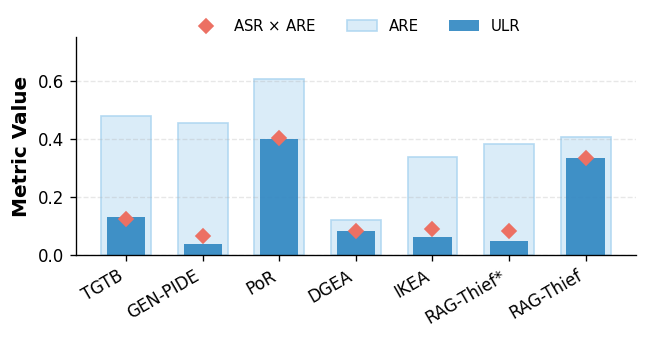

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. 绘图配置
fig, ax = plt.subplots(figsize=(5.5, 3), dpi=120)

x = np.arange(len(plot_df["attack"]))
width_base = 0.65  # 背景柱宽度
width_upper = 0.5 # 前景柱宽度

# --- 核心层 1: ARE (作为背景/基准) ---
ax.bar(x, plot_df["ARE"], width=width_base, color='#D6EAF8', 
       label='ARE', alpha=0.9, edgecolor='#AED6F1', zorder=1)

# --- 核心层 2: ULR (作为实际观测值) ---
# 它是 ARE 的一部分，所以重叠在上面
ax.bar(x, plot_df["ULR"], width=width_upper, color='#2E86C1', 
       label='ULR', alpha=0.9, zorder=2)

# --- 核心层 3: ASR x ARE (作为理论预测) ---
# 用红色折线穿过，观察它是否精准落在 ULR 柱子的顶部
ax.plot(x, plot_df["ASR_x_ARE"], color='#EC7063', 
        marker='D', 
       #  marker='h', 
        markersize=6, 
        linewidth=0, label=r'ASR $\times$ ARE', zorder=3)

# 3. 细节增强
ax.set_ylabel("Metric Value", fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_df["attack"], rotation=30, ha='right')
ax.set_ylim(0, 0.75)

# # 添加数值标注 (可选：如果想强调近似相等的精度)
# for i, val in enumerate(plot_df["ASR_x_ARE"]):
#     ax.text(i, val + 0.02, f'{val:.2f}', color='#C0392B', ha='center', fontsize=8, fontweight='bold')

# 美化边框与网格
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# 调整图例：分两列显示防止拥挤
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False, fontsize=9)

plt.tight_layout()

# 建议设置 transparent=True 以便后续在 PPT 或 LaTeX 中排版
plt.savefig("asr_are_ulr.pdf", format='pdf', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

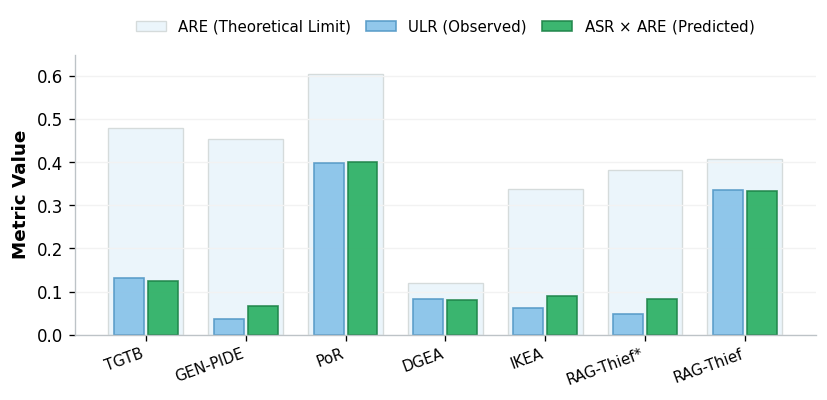

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 核心：手动排序与清洗 ---
custom_order = ['TGTB', 'GEN-PIDE', 'PoR', 'DGEA', 'IKEA', 'RAG-Thief*', 'RAG-Thief']
# 确保数据中没有多余空格
plot_df['attack'] = plot_df['attack'].astype(str).str.strip()
# 应用分类排序，并处理可能出现的匹配失败
plot_df['attack'] = pd.Categorical(plot_df['attack'], categories=custom_order, ordered=True)
plot_df = plot_df.sort_values('attack').dropna(subset=['attack'])

# 2. 绘图设置
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=120)

x = np.arange(len(plot_df["attack"]))
width_bg = 0.75   # 背景大柱宽度
width_sub = 0.30  # 两个并列子柱的宽度

# --- 层 1: ARE (容器大柱 - 浅灰) ---
ax.bar(x, plot_df["ARE"], width=width_bg, color='#EBF5FB', 
       edgecolor='#D5DBDB', linewidth=0.8, label='ARE (Theoretical Limit)', zorder=1)

# --- 层 2: ULR (左侧子柱 - 莫兰迪蓝) ---
ax.bar(x - width_sub/2 - 0.02, plot_df["ULR"], width=width_sub, 
       color='#85C1E9', alpha=0.9, edgecolor='#5499C7', linewidth=1, 
       label='ULR (Observed)', zorder=2)

# --- 层 3: ASR x ARE (右侧子柱 - 莫兰迪绿) ---
# 使用你要求的绿色：#27AE60
ax.bar(x + width_sub/2 + 0.02, plot_df["ASR_x_ARE"], width=width_sub, 
       color='#27AE60', alpha=0.9, edgecolor='#1E8449', linewidth=1, 
       label=r'ASR $\times$ ARE (Predicted)', zorder=2)

# 3. 细节美化
ax.set_ylabel("Metric Value", fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_df["attack"], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 0.65) # 留出顶部空间

# 模仿参考图的网格感
ax.yaxis.grid(True, linestyle='-', color='#F2F2F2', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

# 图例优化
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), 
          ncol=3, frameon=False, fontsize=9, columnspacing=1)

plt.tight_layout()
plt.show()